In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow Version:", tf.__version__)
print("Setup Successful!")

TensorFlow Version: 2.21.0
Setup Successful!


In [7]:
with open("dataset/shakespeare.txt", "r", encoding="utf-8") as file:
    text = file.read()

In [8]:
print(len(text))

1115424


In [9]:
print(text[:500])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [10]:
print(repr(text[:100]))

'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou'


In [11]:
text = text.lower()

In [12]:
print(text[:500])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [13]:
import string

text = text.translate(str.maketrans('', '', string.punctuation))

In [14]:
print(text[:500])

first citizen
before we proceed any further hear me speak

all
speak speak

first citizen
you are all resolved rather to die than to famish

all
resolved resolved

first citizen
first you know caius marcius is chief enemy to the people

all
we knowt we knowt

first citizen
let us kill him and well have corn at our own price
ist a verdict

all
no more talking ont let it be done away away

second citizen
one word good citizens

first citizen
we are accounted poor citizens the patricians good
what 


In [15]:
print("Total Characters:", len(text))

Total Characters: 1061027


In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [17]:
tokenizer = Tokenizer()

In [18]:
tokenizer.fit_on_texts([text])

In [19]:
total_words = len(tokenizer.word_index) + 1

print("Total Words:", total_words)

Total Words: 12850


In [20]:
for word, index in list(tokenizer.word_index.items())[:20]:
    print(index, ":", word)

1 : the
2 : and
3 : to
4 : i
5 : of
6 : you
7 : my
8 : a
9 : that
10 : in
11 : is
12 : not
13 : for
14 : with
15 : me
16 : it
17 : be
18 : your
19 : his
20 : this


In [21]:
sample = "to be or not to be"

sequence = tokenizer.texts_to_sequences([sample])

print(sequence)

[[3, 17, 51, 12, 3, 17]]


In [22]:
input_sequences = []

for line in text.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

In [23]:
print("Total Sequences:", len(input_sequences))

Total Sequences: 169873


In [24]:
print(input_sequences[:5])

[[88, 267], [137, 35], [137, 35, 968], [137, 35, 968, 142], [137, 35, 968, 142, 663]]


In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding="pre"
)

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Maximum Sequence Length:", max_sequence_len)
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

Maximum Sequence Length: 16
X Shape: (169873, 15)
Y Shape: (169873,)


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Build Model
model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=100,
        input_length=max_sequence_len - 1
    ),

    LSTM(150),

    Dense(total_words, activation="softmax")
])

# Compile Model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Model Summary
model.summary()

c:\Users\mohit\OneDrive\Desktop\Generative-AI-LSTM\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
X = X[:50000]
y = y[:50000]

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
) 

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 164ms/step - accuracy: 0.0902 - loss: 6.0313
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 186ms/step - accuracy: 0.1018 - loss: 5.7828
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 150ms/step - accuracy: 0.1093 - loss: 5.5959
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 54s 137ms/step - accuracy: 0.1147 - loss: 5.4346
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 53s 136ms/step - accuracy: 0.1199 - loss: 5.2880
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 163ms/step - accuracy: 0.1236 - loss: 5.1492
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 55s 139ms/step - accuracy: 0.1290 - loss: 5.0160
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 142ms/step - accuracy: 0.1350 - loss: 4.8872
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 92s 166ms/step - accuracy: 0.1404 - loss: 4.7616
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 71s 138ms/step - accuracy: 0.1494 - loss: 4.6377
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 53s 134ms/step - accuracy: 0.1551 - loss: 4.5176
Epoch 12/20
391/391

In [31]:
model.save("lstm_text_generator.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [32]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def generate_text(seed_text, next_words=50):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

print(generate_text("to be", 50))

to be a makepeace shall be so heightend to thee to be a world of a inherited accusers and a commonalty of a end g eternity widowd considerate son and soonbelieving of construction follower follower not not soonbelieving of notion sided shrug lag to be a world to the tower to wales


In [33]:
generated_text = generate_text("to be", 100)

print(generated_text)

with open("generated_output.txt", "w", encoding="utf-8") as file:
    file.write(generated_text)

print("Generated text saved successfully!")

to be a makepeace shall be so heightend to thee to be a world of a inherited accusers and a commonalty of a end g eternity widowd considerate son and soonbelieving of construction follower follower not not soonbelieving of notion sided shrug lag to be a world to the tower to wales you are not to your grace a clout of rome are all a world of him gan pierce yourselfs cockshut yourselfs cockshut tears for soonbelieving for soonbelieving yourselfs harm of morrows sided shrug lag follower soonbelieving yourselfs plague of acceptance of addition shrug to him thus i have heard it
Generated text saved successfully!


In [34]:
from tensorflow.keras.models import load_model

model = load_model("lstm_text_generator.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [35]:
print(generate_text("love is", 50))
print(generate_text("king henry", 50))
print(generate_text("the world", 50))

love is a brace of courtezans a man he is falsely here he is mewd up lag follower not believe harts shrug to soonbelieving and charge me shrug a man he is mewd up to him i am not in his helm notion shrug it atonement the world is firm considerate considerate
king henry iii services were well but i am a man to see him to the tower of york he is not so much yes of my soul i am not in the inherited accusers and a sugard yourselfs corrupting fie husewife on accusers g on him shrug i soonbelieving yourselfs yourselfs
the world is cheered by the field and ears to me the world of the inherited us not the world g insolent end of the sunrising pratest have made a nap scarfs strengths entangled hereditary lamberts inherited the inherited accusers conduits scoffs it considerate considerate yourselfs cockshut more yourselfs yourselfs son my


Matplotlib is building the font cache; this may take a moment.


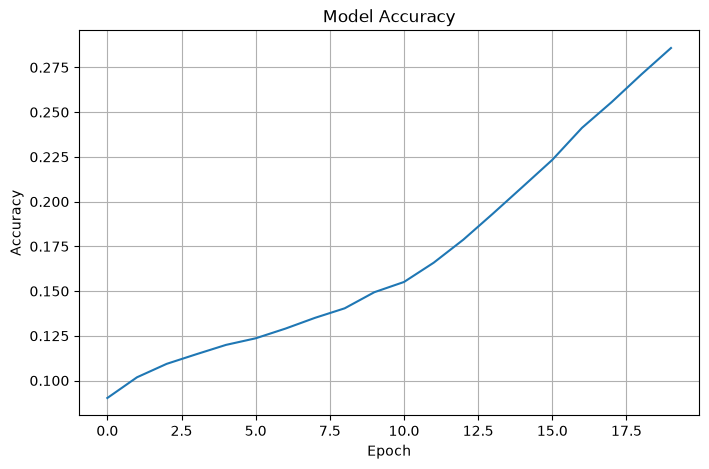

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

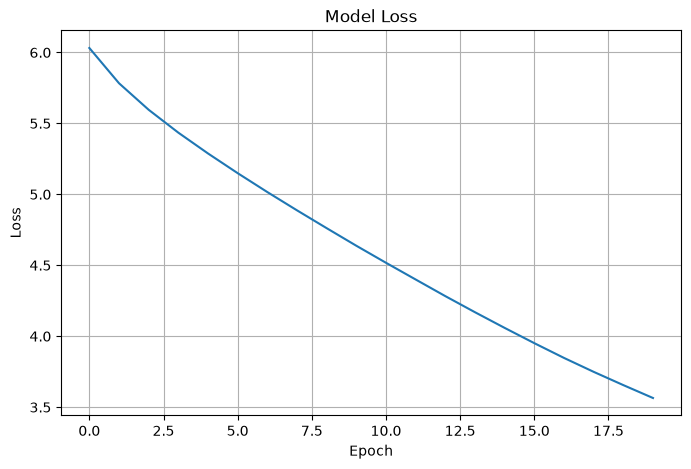

In [38]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()